# Exploratory analysis of the final Jeopardy! data

This notebook describes the **final MI3 sample** using `final_contestant_games.csv` and the connected raw contestant-clue file already in `Project_1/Data`. It selects the final games and keeps one copy of each clue. It focuses on counts, missingness, occupation text, clue topics, and uncertainty in optional SOC/CIP links. It does **not** train a winner model. The winner label is shown only in a descriptive check, never used to generate occupation or clue features.

**In Google Colab:** upload `final_contestant_games.csv` and `jeopardy_raw_contestant_clue_data.csv.gz` using the Files panel, or mount Drive and set `DATA_DIR` below to their folder. Run the cells from top to bottom. The compressed raw file can be read directly; it does not need to be extracted. The code reads it in chunks to avoid loading all repeated clue rows at once.


In [2]:
from pathlib import Path
from collections import Counter
import html
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

DATA_DIR = Path(".")  # Change this if your files are in Google Drive.
OUT_DIR = Path("eda_final_outputs")
OUT_DIR.mkdir(exist_ok=True)

PEOPLE_FILE = DATA_DIR / "final_contestant_games.csv"
RAW_FILE = DATA_DIR / "jeopardy_raw_contestant_clue_data.csv.gz"
if not RAW_FILE.exists():
    RAW_FILE = DATA_DIR / "jeopardy_raw_contestant_clue_data.csv"

for path in [PEOPLE_FILE, RAW_FILE]:
    if not path.is_file():
        raise FileNotFoundError(f"{path} is missing. Check DATA_DIR and the filename.")

people = pd.read_csv(
    PEOPLE_FILE,
    dtype={"proposed_soc_code": str, "proposed_onet_soc_code": str},
)
people["air_date"] = pd.to_datetime(people["air_date"], errors="coerce")
game_ids = set(people["game_id"])

# Check the file contents rather than trusting the .gz extension.
with RAW_FILE.open("rb") as source:
    signature = source.read(128)

if signature.startswith(bytes([31, 139])):
    raw_compression = "gzip"
elif b"game_id" in signature:
    raw_compression = None
else:
    raise ValueError(
        f"{RAW_FILE} does not appear to be a gzip file or the expected CSV. "
        f"First bytes: {signature[:40]!r}"
    )

print("Raw file format:", "gzip" if raw_compression else "plain CSV")

raw_columns = [
    "game_id", "clue_source_record_id", "clue_source", "round",
    "category", "clue_text", "clue_value", "daily_double_flag",
]

parts = []
for chunk in pd.read_csv(
    RAW_FILE,
    compression=raw_compression,
    usecols=raw_columns,
    chunksize=100_000,
    low_memory=False,
):
    chunk = chunk[chunk["game_id"].isin(game_ids)]
    parts.append(
        chunk.drop_duplicates(["game_id", "clue_source_record_id"])
    )

clues = (
    pd.concat(parts, ignore_index=True)
    .drop_duplicates(["game_id", "clue_source_record_id"])
    .reset_index(drop=True)
)

def clean_text(value):
    if pd.isna(value):
        return ""
    value = html.unescape(str(value))
    return re.sub(r"\s+", " ", re.sub(r"<[^>]+>", " ", value)).strip()

clues["category_text"] = clues["category"].map(clean_text)
clues["clue_text_for_model"] = clues["clue_text"].map(clean_text)
clues["clue_text_missing"] = clues["clue_text_for_model"].eq("").astype(int)
clues["is_final_jeopardy"] = clues["round"].eq("FJ!").astype(int)

# The raw source uses 0 for Final Jeopardy, which has no fixed face value.
clues.loc[clues["is_final_jeopardy"].eq(1), "clue_value"] = np.nan
clues["clue_value"] = pd.to_numeric(clues["clue_value"], errors="coerce")

round_max = clues["clue_value"].groupby(
    [clues["game_id"], clues["round"]]
).transform("max")
clues["relative_clue_value"] = (
    clues["clue_value"] / round_max
).round(4)
clues["high_value_clue"] = (
    clues["relative_clue_value"].ge(0.8).astype(int)
)

print(
    f"Loaded {len(people):,} contestant-game rows "
    f"and {len(clues):,} distinct clues"
)

Matplotlib is building the font cache; this may take a moment.


Raw file format: gzip
Loaded 11,646 contestant-game rows and 225,388 distinct clues


## 1. Check the unit of analysis

The contestant table should contain exactly three rows per game and one winner. The clue table should have one row per distinct recorded clue. These checks catch accidental duplication after a join. A person can appear in more than one game.


In [3]:
game_sizes = people.groupby('game_id').size()
winner_counts = people.groupby('game_id')['is_winner'].sum()
clue_counts = clues.groupby('game_id').size()

overview = pd.DataFrame({
    'measure': ['Games', 'Unique contestants', 'Contestant-game rows', 'Unique clue rows',
                'First air date', 'Last air date', 'Median clues per game',
                'Min clues per game', 'Max clues per game',
                'Games with exactly 3 contestants', 'Games with exactly 1 winner'],
    'value': [people.game_id.nunique(), people.contestant_id.nunique(), len(people), len(clues),
              str(people.air_date.min().date()), str(people.air_date.max().date()),
              float(clue_counts.median()), int(clue_counts.min()), int(clue_counts.max()),
              int(game_sizes.eq(3).sum()), int(winner_counts.eq(1).sum())]
})
display(overview)
assert game_sizes.eq(3).all()
assert winner_counts.eq(1).all()
assert clue_counts.ge(50).all()
assert set(people.game_id) == set(clues.game_id)
assert not people.duplicated(['game_id', 'contestant_id']).any()
assert not clues.duplicated(['game_id', 'clue_source_record_id']).any()
overview.to_csv(OUT_DIR / 'sample_overview.csv', index=False)


,measure,value
0,Games,3882
1,Unique contestants,8026
2,Contestant-game rows,11646
3,Unique clue rows,225388
4,First air date,1984-09-28
5,Last air date,2019-07-26
6,Median clues per game,59.0
7,Min clues per game,50
8,Max clues per game,61
9,Games with exactly 3 contestants,3882


## 2. How complete are the retained boards?

The cutoff is 50 recorded clues, but a game can still have fewer than a full board. Count clues **from the clue table**, rather than multiplying by three using the joined contestant-clue file. The first plot is useful for the MI3 data description.


,clue_count,games
0,50,35
1,51,62
2,52,64
3,53,105
4,54,146
5,55,237
6,56,288
7,57,409
8,58,502
9,59,635


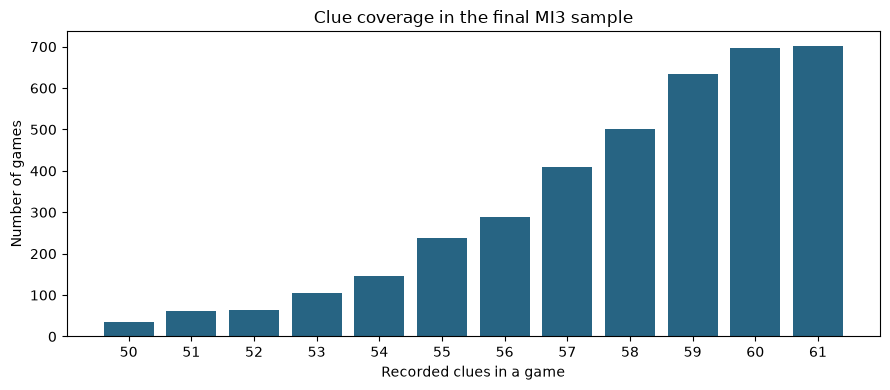

In [4]:
coverage = clue_counts.value_counts().sort_index().rename_axis('clue_count').reset_index(name='games')
display(coverage)
coverage.to_csv(OUT_DIR / 'games_by_clue_count.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(coverage.clue_count, coverage.games, color='#276483')
ax.set(xlabel='Recorded clues in a game', ylabel='Number of games',
       title='Clue coverage in the final MI3 sample')
ax.set_xticks(range(50, 62))
fig.tight_layout()
fig.savefig(OUT_DIR / 'games_by_clue_count.png', dpi=160)
plt.show()


## 3. Missing text and available rounds

Final Jeopardy has no fixed face value, so its `relative_clue_value` is expected to be blank. Multimedia clues may still lack important information even when their text field is nonempty.


In [5]:
text_check = pd.DataFrame({
    'field': ['Occupation text (contestant-game)', 'Category text (clue)',
              'Clue text (clue)', 'Clue value (clue)', 'Relative value (non-FJ clue)'],
    'blank_count': [int(people.occupation_text_for_model.fillna('').str.strip().eq('').sum()),
                    int(clues.category_text.fillna('').str.strip().eq('').sum()),
                    int(clues.clue_text_for_model.fillna('').str.strip().eq('').sum()),
                    int(clues.clue_value.isna().sum()),
                    int(clues.loc[clues.is_final_jeopardy.eq(0), 'relative_clue_value'].isna().sum())]
})
display(text_check)
round_summary = clues.groupby('round', dropna=False).agg(
    clues=('clue_source_record_id', 'size'),
    games=('game_id', 'nunique'),
    high_value_clues=('high_value_clue', 'sum'),
    median_clue_words=('clue_text_for_model', lambda s: s.fillna('').str.split().str.len().median())
).reset_index()
display(round_summary)
text_check.to_csv(OUT_DIR / 'missing_text.csv', index=False)
round_summary.to_csv(OUT_DIR / 'round_summary.csv', index=False)


,field,blank_count
0,Occupation text (contestant-game),0
1,Category text (clue),0
2,Clue text (clue),0
3,Clue value (clue),3825
4,Relative value (non-FJ clue),0


,round,clues,games,high_value_clues,median_clue_words
0,DJ!,110198,3882,43389,15.0
1,FJ!,3825,3825,0,18.0
2,J!,111365,3882,43926,15.0


## 4. What topics occur on the boards?

The category table and plot count **clues**, not unique games. A recurring category therefore contributes several clues. Categories can use wordplay, so exact category names are only a simple description of the board, not the semantic score used by the model.


,category,clues
0,SCIENCE,546
1,LITERATURE,534
2,AMERICAN HISTORY,487
3,POTPOURRI,482
4,WORLD HISTORY,455
5,SPORTS,452
6,BEFORE & AFTER,440
7,HISTORY,438
8,BUSINESS & INDUSTRY,408
9,WORLD GEOGRAPHY,396


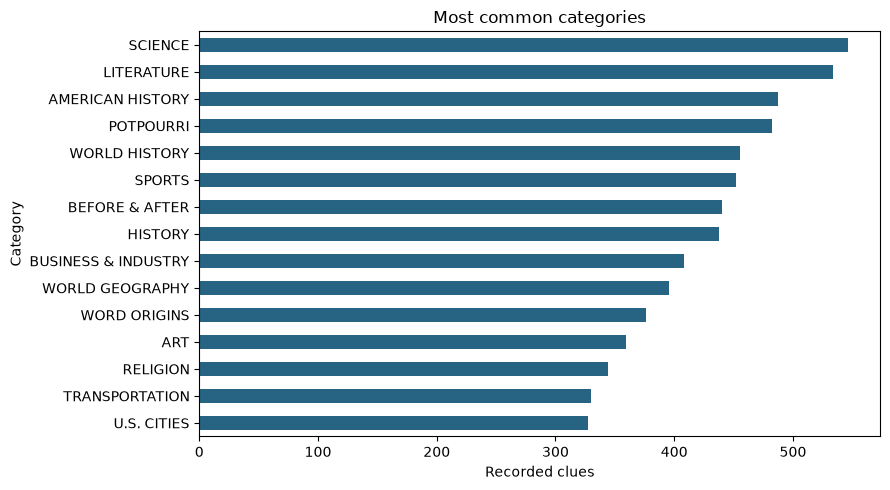

In [6]:
top_categories = clues.category_text.fillna('[missing]').value_counts().head(15)
display(top_categories.rename_axis('category').reset_index(name='clues'))
top_categories.rename_axis('category').reset_index(name='clues').to_csv(
    OUT_DIR / 'top_categories.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 5))
top_categories.sort_values().plot.barh(ax=ax, color='#276483')
ax.set(xlabel='Recorded clues', ylabel='Category', title='Most common categories')
fig.tight_layout()
fig.savefig(OUT_DIR / 'top_categories.png', dpi=160)
plt.show()


## 5. Describe the occupation and clue wording

These are plain word counts for understanding the material. The small stop-word list removes common function words; it is **not** a trained vocabulary. Count one occupation phrase per contestant-game and each clue once. Do not use whole-dataset word frequencies to select model features after reserving a test set.


In [7]:
STOP = {'a', 'an', 'the', 'and', 'or', 'of', 'in', 'to', 'for', 'with', 'from',
        'at', 'on', 'is', 'was', 'are', 'were', 'who', 'what', 'which', 'this',
        'that', 'it', 'its', 'as', 'by', 'his', 'her', 'their', 'one', 'first',
        'these', "it's", 'you', 'when', 'has', 'have', 'named', 'called', 'about',
        'but', 'like', 'not', 'can', 'name', 'after', 'new'}

def common_words(series, top=20):
    counts = Counter()
    for value in series.dropna().astype(str):
        counts.update(word for word in re.findall(r"[a-z]+(?:'[a-z]+)?", value.lower())
                      if word not in STOP and len(word) > 2)
    return pd.DataFrame(counts.most_common(top), columns=['word', 'occurrences'])

print('Common occupation words:')
occupation_words = common_words(people.occupation_text_for_model)
display(occupation_words)
print('Common clue words:')
clue_words = common_words(clues.clue_text_for_model)
display(clue_words)

lengths = pd.DataFrame({
    'occupation_words': people.occupation_text_for_model.fillna('').str.split().str.len(),
})
print('Occupation words per contestant-game:')
display(lengths.occupation_words.describe().to_frame(name='value'))
print('Clue words per unique clue:')
display(clues.clue_text_for_model.fillna('').str.split().str.len().describe().to_frame(name='value'))
occupation_words.to_csv(OUT_DIR / 'occupation_words.csv', index=False)
clue_words.to_csv(OUT_DIR / 'clue_words.csv', index=False)


Common occupation words:


,word,occurrences
0,teacher,1225
1,writer,702
2,manager,684
3,attorney,655
4,school,566
5,engineer,437
6,assistant,413
7,editor,399
8,analyst,396
9,high,391


Common clue words:


,word,occurrences
0,city,7077
1,country,5104
2,man,5047
3,type,5042
4,word,5009
5,clue,4892
6,state,4800
7,she,4793
8,film,4633
9,used,4534


Occupation words per contestant-game:


,value
count,11646.000000
mean,2.321054
std,1.249356
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,15.000000


Clue words per unique clue:


,value
count,225388.000000
mean,14.613307
std,5.921577
min,1.000000
25%,11.000000
50%,15.000000
75%,18.000000
max,78.000000


## 6. SOC and CIP uncertainty (optional for the main model)

The main analysis can use occupation phrases without these mappings. A proposed SOC title can be wrong, especially in the `very_low` tiers. CIP codes are *possible educational programs linked to a job*, not proof of any contestant's degree. A single SOC can have many candidate CIPs; `no_crosswalk_program` means there is no official CIP match for that proposed SOC.


In [8]:
tier_summary = (people.soc_uncertainty_level.value_counts(dropna=False)
    .rename_axis('SOC uncertainty tier').reset_index(name='contestant_games'))
tier_summary['percent'] = (100 * tier_summary.contestant_games / len(people)).round(1)
display(tier_summary)

cip_summary = (people.cip_mapping_status.value_counts(dropna=False)
    .rename_axis('CIP mapping status').reset_index(name='contestant_games'))
cip_summary['percent'] = (100 * cip_summary.contestant_games / len(people)).round(1)
display(cip_summary)

print('Candidate CIP codes per contestant-game:')
display(people.cip_candidate_count.describe(percentiles=[.25, .5, .75, .9, .95]).to_frame(name='value'))
print('Games with three high/medium SOC matches:',
      int(people.soc_uncertainty_level.isin(['high_exact_title', 'medium_curated_match'])
          .groupby(people.game_id).sum().eq(3).sum()))
tier_summary.to_csv(OUT_DIR / 'soc_uncertainty_summary.csv', index=False)
cip_summary.to_csv(OUT_DIR / 'cip_mapping_summary.csv', index=False)


,SOC uncertainty tier,contestant_games,percent
0,medium_curated_match,3242,27.8
1,low_contextual_role,3060,26.3
2,very_low_approximate,1933,16.6
3,very_low_weak_guess,1052,9.0
4,low_multiple_roles,944,8.1
5,low_broad_role,612,5.3
6,high_exact_title,544,4.7
7,very_low_multiple_roles,259,2.2


,CIP mapping status,contestant_games,percent
0,multiple_possible_programs,10427,89.5
1,one_crosswalk_program,642,5.5
2,no_crosswalk_program,577,5.0


Candidate CIP codes per contestant-game:


,value
count,11646.000000
mean,24.866306
std,35.077017
min,0.000000
25%,5.000000
50%,11.000000
75%,26.000000
90%,92.000000
95%,127.000000
max,210.000000


Games with three high/medium SOC matches: 140


## 7. Simple winner-label check

This describes the target and may help the baseline-model team assess contestant ordering. It does **not** measure how well occupation text predicts winners. The source's position ordering could encode returning champions; do not assume it is random.


In [9]:
position_summary = people.groupby('contestant_position', dropna=False).agg(
    contestant_games=('is_winner', 'size'),
    wins=('is_winner', 'sum'),
).reset_index()
position_summary['win_rate'] = (position_summary.wins / position_summary.contestant_games).round(4)
display(position_summary)
position_summary.to_csv(OUT_DIR / 'winner_rate_by_position.csv', index=False)

print('Exploration complete. CSV summaries and two plots are saved in:', OUT_DIR.resolve())


,contestant_position,contestant_games,wins,win_rate
0,1,3882,1150,0.2962
1,2,3882,1389,0.3578
2,3,3882,1343,0.3460


Exploration complete. CSV summaries and two plots are saved in: /Users/Bhargav/Code/DS4002-SLMB/Project_1/Data/eda_final_outputs
